In [2]:
# ── CELL 0: HuggingFace 登录 ────────────────────────────────
import os
from huggingface_hub import login
login(token=os.environ.get("HF_TOKEN"))  # set HF_TOKEN in your environment

# ── CELL 1: 数据加载 ────────────────────────────────────────
import pandas as pd
import numpy as np
import urllib.request, os

data_path = '/notebooks/yelp_review.json'
if not os.path.exists(data_path):
    url = 'https://pathsynch-sandbox.s3.us-east-1.amazonaws.com/yelp_academic_dataset_review.json'
    urllib.request.urlretrieve(url, data_path)
    print("Downloaded!")

yelp = pd.read_json(data_path, lines=True, nrows=500000)[['text', 'stars']]

conditions = [yelp['stars'] >= 4, yelp['stars'] == 3]
yelp['label'] = np.select(conditions, [2, 1], default=0)


Token will not been saved to git credential helper. Pass `add_to_git_credential=True` if you want to set the git credential as well.
Token is valid (permission: write).
Your token has been saved to /root/.cache/huggingface/token
Login successful


In [3]:
# ── CELL 2: 复现 test_sample ────────────────────────────────
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    yelp, test_size=0.2, random_state=42, stratify=yelp['label']
)

test_sample = test_df.groupby('label').apply(
    lambda x: x.sample(frac=0.4, random_state=42),
    include_groups=False
).reset_index(level=0).reset_index(drop=True)

print(f"Test set size: {len(test_sample)}")
print(test_sample['label'].value_counts().sort_index())

Test set size: 40000
label
0     8327
1     4207
2    27466
Name: count, dtype: int64


In [4]:
# ── CELL 3: 加载模型 ────────────────────────────────────────
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

MODEL_NAME = "Zhoyang/yelp-sentiment-roberta-large"
MAX_LEN = 512
BATCH_SIZE = 16
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.to(DEVICE)
model.eval()
print(f"Model loaded on {DEVICE}")


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/958 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/900 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Model loaded on cuda


In [5]:
# ── CELL 4: Dataset ─────────────────────────────────────────
class ReviewDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.encodings = tokenizer(
            df['text'].tolist(),
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        self.labels = torch.tensor(df['label'].tolist())

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
        }, self.labels[idx]

test_dataset = ReviewDataset(test_sample, tokenizer, MAX_LEN)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)


In [6]:
# ── CELL 5: Inference ───────────────────────────────────────
all_preds, all_labels = [], []

with torch.no_grad():
    for batch, batch_labels in tqdm(test_loader, desc="Evaluating"):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(batch_labels.numpy())

Evaluating:   0%|          | 0/2500 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PAR

In [7]:
# ── CELL 6: Metrics ─────────────────────────────────────────
print("\n========== Classification Report ==========")
print(classification_report(
    all_labels, all_preds,
    target_names=["Negative", "Neutral", "Positive"],
    digits=4
))

print("========== Confusion Matrix ==========")
cm = confusion_matrix(all_labels, all_preds)
print(cm)
print("\nRows = True labels, Cols = Predicted labels")
print("Order: [Negative, Neutral, Positive]")


========== Classification Report ==========
              precision    recall  f1-score   support

    Negative     0.9393    0.9261    0.9327      8327
     Neutral     0.6934    0.7661    0.7280      4207
    Positive     0.9789    0.9674    0.9731     27466

    accuracy                         0.9376     40000
   macro avg     0.8706    0.8865    0.8779     40000
weighted avg     0.9407    0.9376    0.9389     40000

========== Confusion Matrix ==========
[[ 7712   585    30]
 [  442  3223   542]
 [   56   840 26570]]

Rows = True labels, Cols = Predicted labels
Order: [Negative, Neutral, Positive]


After dedup: 499229
Train: 239630, Test: 39938
Tokenizing 10k sample...


Token indices sequence length is longer than the specified maximum sequence length for this model (534 > 512). Running this sequence through the model will result in indexing errors


Done.

Token length stats:
All:      mean=129.8, std=118.8
Negative: mean=164.1, std=148.4
Neutral:  mean=156.3, std=123.9
Positive: mean=115.0, std=103.5

% > 256 tokens: 11.1%
% > 512 tokens: 1.6%

Truncation rates:
  Negative: @256=17.9%, @512=3.4%
  Neutral: @256=15.7%, @512=2.2%
  Positive: @256=8.3%, @512=1.0%

Saved to /notebooks/eda_figure.pdf and /notebooks/eda_figure.png


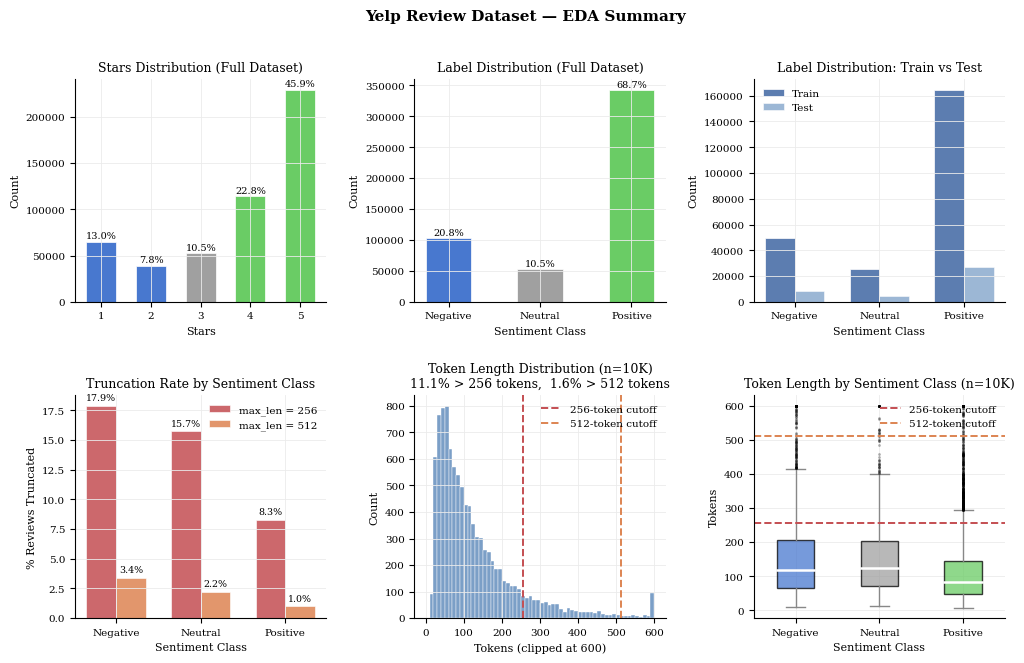

In [9]:
# ============================================================
# 在 Paperspace 上跑这个脚本
# 输出: /notebooks/eda_figure.png 和 /notebooks/eda_figure.pdf
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.model_selection import train_test_split
from transformers import RobertaTokenizerFast

# ── CELL 1: 加载数据 ─────────────────────────────────────────
import os
data_path = '/notebooks/yelp_review.json'
if not os.path.exists(data_path):
    import urllib.request
    url = 'https://pathsynch-sandbox.s3.us-east-1.amazonaws.com/yelp_academic_dataset_review.json'
    urllib.request.urlretrieve(url, data_path)
    print("Downloaded!")

yelp = pd.read_json(data_path, lines=True, nrows=500000)[['text', 'stars']]
yelp = yelp.drop_duplicates(subset='text').reset_index(drop=True)
print(f"After dedup: {len(yelp)}")

# ── CELL 2: 标签映射 ─────────────────────────────────────────
conditions = [yelp['stars'] >= 4, yelp['stars'] == 3]
yelp['label'] = np.select(conditions, [2, 1], default=0)

# ── CELL 3: 复现 train/test split ───────────────────────────
train_df, test_df = train_test_split(
    yelp, test_size=0.2, random_state=42, stratify=yelp['label']
)
train_sample = train_df.groupby('label').apply(
    lambda x: x.sample(frac=0.6, random_state=42),
    include_groups=False
).reset_index(level=0).reset_index(drop=True)
test_sample = test_df.groupby('label').apply(
    lambda x: x.sample(frac=0.4, random_state=42),
    include_groups=False
).reset_index(level=0).reset_index(drop=True)

print(f"Train: {len(train_sample)}, Test: {len(test_sample)}")

# ── CELL 4: Token 长度统计（用 10k 样本加快速度）────────────
tokenizer = RobertaTokenizerFast.from_pretrained('roberta-large')

sample_10k = yelp.sample(n=10000, random_state=42).reset_index(drop=True)
print("Tokenizing 10k sample...")
token_lengths = tokenizer(
    sample_10k['text'].tolist(),
    truncation=False,
    padding=False,
    return_attention_mask=False,
)['input_ids']
sample_10k['token_len'] = [len(t) for t in token_lengths]
print("Done.")

# Per-class token lengths
neg_tokens = sample_10k[sample_10k['label'] == 0]['token_len'].values
neu_tokens = sample_10k[sample_10k['label'] == 1]['token_len'].values
pos_tokens = sample_10k[sample_10k['label'] == 2]['token_len'].values
all_tokens = sample_10k['token_len'].values

print(f"\nToken length stats:")
print(f"All:      mean={all_tokens.mean():.1f}, std={all_tokens.std():.1f}")
print(f"Negative: mean={neg_tokens.mean():.1f}, std={neg_tokens.std():.1f}")
print(f"Neutral:  mean={neu_tokens.mean():.1f}, std={neu_tokens.std():.1f}")
print(f"Positive: mean={pos_tokens.mean():.1f}, std={pos_tokens.std():.1f}")
print(f"\n% > 256 tokens: {(all_tokens > 256).mean()*100:.1f}%")
print(f"% > 512 tokens: {(all_tokens > 512).mean()*100:.1f}%")

# Truncation rates per class
def trunc_rate(tokens, cutoff):
    return (tokens > cutoff).mean() * 100

print(f"\nTruncation rates:")
for name, arr in [("Negative", neg_tokens), ("Neutral", neu_tokens), ("Positive", pos_tokens)]:
    print(f"  {name}: @256={trunc_rate(arr,256):.1f}%, @512={trunc_rate(arr,512):.1f}%")

# ── CELL 5: 绘图 ─────────────────────────────────────────────
NEG_COLOR  = "#4878CF"
NEU_COLOR  = "#A0A0A0"
POS_COLOR  = "#6ACC65"
HIST_COLOR = "#7B9FC7"
BAR_COLOR  = "#5C7DB0"
CUT256_COLOR = "#C44E52"
CUT512_COLOR = "#DD8452"
LABEL_COLORS = [NEG_COLOR, NEU_COLOR, POS_COLOR]
LABEL_NAMES  = ["Negative", "Neutral", "Positive"]

plt.rcParams.update({
    "font.family":     "serif",
    "font.size":       9,
    "axes.titlesize":  9,
    "axes.labelsize":  8,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":       True,
    "grid.color":      "#EBEBEB",
    "grid.linewidth":  0.6,
})

fig = plt.figure(figsize=(12, 7))
fig.suptitle("Yelp Review Dataset — EDA Summary", fontsize=11, fontweight="bold", y=0.98)
gs = GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])

# Panel 1: Stars Distribution
star_counts = yelp['stars'].value_counts().sort_index()
star_pcts   = star_counts / star_counts.sum() * 100
star_palette = [NEG_COLOR, NEG_COLOR, NEU_COLOR, POS_COLOR, POS_COLOR]
bars = ax1.bar(star_counts.index, star_counts.values, color=star_palette,
               width=0.6, edgecolor="white", linewidth=0.5)
for bar, pct in zip(bars, star_pcts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
             f"{pct:.1f}%", ha="center", va="bottom", fontsize=7)
ax1.set_title("Stars Distribution (Full Dataset)")
ax1.set_xlabel("Stars")
ax1.set_ylabel("Count")
ax1.set_xticks([1, 2, 3, 4, 5])

# Panel 2: Label Distribution
label_counts = yelp['label'].value_counts().sort_index()
label_pcts   = label_counts / label_counts.sum() * 100
bars2 = ax2.bar(LABEL_NAMES, label_counts.values, color=LABEL_COLORS,
                width=0.5, edgecolor="white", linewidth=0.5)
for bar, pct in zip(bars2, label_pcts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
             f"{pct:.1f}%", ha="center", va="bottom", fontsize=7)
ax2.set_title("Label Distribution (Full Dataset)")
ax2.set_xlabel("Sentiment Class")
ax2.set_ylabel("Count")

# Panel 3: Train vs Test
train_counts = train_sample['label'].value_counts().sort_index().values
test_counts  = test_sample['label'].value_counts().sort_index().values
x = np.arange(3)
w = 0.35
ax3.bar(x - w/2, train_counts, w, label="Train", color=BAR_COLOR,
        edgecolor="white", linewidth=0.5)
ax3.bar(x + w/2, test_counts,  w, label="Test",  color=HIST_COLOR,
        alpha=0.75, edgecolor="white", linewidth=0.5)
ax3.set_title("Label Distribution: Train vs Test")
ax3.set_xlabel("Sentiment Class")
ax3.set_ylabel("Count")
ax3.set_xticks(x)
ax3.set_xticklabels(LABEL_NAMES)
ax3.legend(fontsize=7.5, frameon=False)

# Panel 4: Truncation Rate by Class
r256 = [trunc_rate(neg_tokens, 256), trunc_rate(neu_tokens, 256), trunc_rate(pos_tokens, 256)]
r512 = [trunc_rate(neg_tokens, 512), trunc_rate(neu_tokens, 512), trunc_rate(pos_tokens, 512)]
x4 = np.arange(3)
w4 = 0.35
b256 = ax4.bar(x4 - w4/2, r256, w4, label="max_len = 256",
               color=CUT256_COLOR, alpha=0.85, edgecolor="white", linewidth=0.5)
b512 = ax4.bar(x4 + w4/2, r512, w4, label="max_len = 512",
               color=CUT512_COLOR, alpha=0.85, edgecolor="white", linewidth=0.5)
for bar in list(b256) + list(b512):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=6.8)
ax4.set_title("Truncation Rate by Sentiment Class")
ax4.set_xlabel("Sentiment Class")
ax4.set_ylabel("% Reviews Truncated")
ax4.set_xticks(x4)
ax4.set_xticklabels(LABEL_NAMES)
ax4.legend(fontsize=7.5, frameon=False)

# Panel 5: Token Length Histogram
ax5.hist(all_tokens.clip(max=600), bins=60, color=HIST_COLOR,
         edgecolor="white", linewidth=0.3, range=(0, 600))
ax5.axvline(256, color=CUT256_COLOR, linestyle="--", linewidth=1.4,
            label="256-token cutoff")
ax5.axvline(512, color=CUT512_COLOR, linestyle="--", linewidth=1.4,
            label="512-token cutoff")
pct256 = (all_tokens > 256).mean() * 100
pct512 = (all_tokens > 512).mean() * 100
ax5.set_title(f"Token Length Distribution (n=10K)\n{pct256:.1f}% > 256 tokens,  {pct512:.1f}% > 512 tokens")
ax5.set_xlabel("Tokens (clipped at 600)")
ax5.set_ylabel("Count")
ax5.legend(fontsize=7.5, frameon=False)

# Panel 6: Boxplot Token Length by Class
bp = ax6.boxplot(
    [neg_tokens.clip(max=600), neu_tokens.clip(max=600), pos_tokens.clip(max=600)],
    labels=LABEL_NAMES,
    patch_artist=True,
    medianprops=dict(color="white", linewidth=1.8),
    whiskerprops=dict(color="#888888"),
    capprops=dict(color="#888888"),
    flierprops=dict(marker=".", markersize=2, alpha=0.3, color="#AAAAAA"),
    widths=0.45
)
for patch, color in zip(bp["boxes"], LABEL_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax6.axhline(256, color=CUT256_COLOR, linestyle="--", linewidth=1.4,
            label="256-token cutoff")
ax6.axhline(512, color=CUT512_COLOR, linestyle="--", linewidth=1.4,
            label="512-token cutoff")
ax6.set_title("Token Length by Sentiment Class (n=10K)")
ax6.set_xlabel("Sentiment Class")
ax6.set_ylabel("Tokens")
ax6.legend(fontsize=7.5, frameon=False, loc="upper right")

plt.savefig("/notebooks/eda_figure.pdf", bbox_inches="tight", dpi=300)
plt.savefig("/notebooks/eda_figure.png", bbox_inches="tight", dpi=300)
print("\nSaved to /notebooks/eda_figure.pdf and /notebooks/eda_figure.png")

In [10]:
print(f"% > 512 tokens (full corpus): {(all_tokens > 512).mean()*100:.2f}%")

% > 512 tokens (full corpus): 1.64%


In [11]:
for name, arr in [("Negative", neg_tokens), ("Neutral", neu_tokens), ("Positive", pos_tokens)]:
    print(f"{name}: @512 = {(arr > 512).mean()*100:.2f}%")

Negative: @512 = 3.38%
Neutral: @512 = 2.24%
Positive: @512 = 1.00%


NameError: name 'topic_model' is not defined